# EDA — Retail Sales Forecasting (Sample Superstore)

**Dataset:** `data/sample_superstore.csv` &nbsp;|&nbsp; **Target:** Sales &nbsp;|&nbsp; **Kolom tanggal:** Order Date
 &nbsp;|&nbsp; **Model:** Prophet bulanan & mingguan &nbsp;|&nbsp; **Dashboard:** Streamlit (`app.py` + `pages/`)

## 1. Pendahuluan

### Tujuan project

Membangun dashboard interaktif dan model **Prophet** (level bulanan + mingguan) untuk forecast permintaan retail — mencegah overstock/stockout, merencanakan inventory, dan menetapkan target penjualan.

### Tujuan EDA

Memahami kualitas data, tren, musiman, dan kontribusi bisnis **sebelum** modelling — agar level agregasi (M/W) dan pilihan Prophet berdasar bukti, bukan asumsi.

### Hubungan EDA dengan forecasting

EDA menjawab tiga hal: level agregasi yang tepat (harian berisik → M/W), pola musiman yang wajib ditangkap model (peak Q4, tren YoY), dan kesiapan series (kontinuitas, stasioneritas visual).

In [6]:
try:
    from IPython.display import display
except ImportError:
    display = print
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 13,
                     "axes.titleweight": "bold", "axes.labelsize": 11,
                     "xtick.labelsize": 9, "ytick.labelsize": 9})
C_SALES = "#2C5F8A"
C_PROFIT = "#2E8B57"

BASE = os.getcwd()
FIG = os.path.join(BASE, "figures")
os.makedirs(FIG, exist_ok=True)

def vlabel(ax, fmt="$%.0f"):
    """Value label di tiap bar."""
    for c in ax.containers:
        try:
            ax.bar_label(c, fmt=fmt, fontsize=8)
        except Exception:
            pass

print("root:", BASE)

root: d:\DATA ANALIS\BC\Forecasting


## 2. Dataset Overview

Memuat data persis seperti `pages/Sales_Dashboard.py` (`encoding="latin1"`, `Order Date` → datetime).

In [2]:
df = pd.read_csv(os.path.join(BASE, "data", "sample_superstore.csv"), encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
print("Rows:", len(df), "| Cols:", df.shape[1])
print("Kolom:", list(df.columns))

Rows: 9994 | Cols: 21
Kolom: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:
print(df.dtypes.to_string())
print("\nRentang Order Date:", df["Order Date"].min().date(), "->", df["Order Date"].max().date())

In [7]:
print("Missing total:", int(df.isnull().sum().sum()))
print("Duplikat:", int(df.duplicated().sum()))
display(df[["Sales", "Profit", "Quantity", "Discount"]].describe().round(2))

Missing total: 0
Duplikat: 0


,Sales,Profit,Quantity,Discount
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,28.66,3.79,0.16
std,623.25,234.26,2.23,0.21
min,0.44,-6599.98,1.00,0.00
25%,17.28,1.73,2.00,0.00
50%,54.49,8.67,3.00,0.20
75%,209.94,29.36,5.00,0.20
max,22638.48,8399.98,14.00,0.80


**Interpretasi**

- 9.994 baris × 21 kolom, rentang 2014–2017 (~4 tahun) — cukup untuk seasonal Prophet.
- **Nol missing, nol duplikat** — tanpa imputasi/drop, risiko bias nol.
- Mean Sales ($230) >> median ($54) — distribusi **right-skew**, sedikit order besar menarik rata-rata.
- 1.871 baris Profit negatif — sinyal promo merugikan, dibahas di Section 8–9.

## 3. Data Cleaning

Prinsip: hanya yang terbukti perlu. Audit Section 2 (nol missing/duplikat) → cleaning = konversi datetime + verifikasi, tanpa drop/imputasi.

In [8]:
dfc = df.copy()
dfc["Order Date"] = pd.to_datetime(dfc["Order Date"], errors="coerce")
assert dfc["Order Date"].isnull().sum() == 0
n0 = len(dfc)
dfc = dfc.drop_duplicates()
print(f"drop_duplicates: {n0} -> {len(dfc)} (0 baris hilang, sesuai audit)")
print("Profit<0 dipertahankan:", int((dfc["Profit"] < 0).sum()), "(info promo, bukan error)")
dfc = dfc.sort_values("Order Date").reset_index(drop=True)
print("Range final:", dfc["Order Date"].min().date(), "->", dfc["Order Date"].max().date())

drop_duplicates: 9994 -> 9994 (0 baris hilang, sesuai audit)
Profit<0 dipertahankan: 1871 (info promo, bukan error)
Range final: 2014-01-03 -> 2017-12-30


## 4. Time Series Analysis

Agregasi harian + MA7/MA30 untuk memisahkan sinyal dari noise — fondasi pilihan agregasi M/W di `pages/Forecasting.py`.

### Tren harian + Moving Average

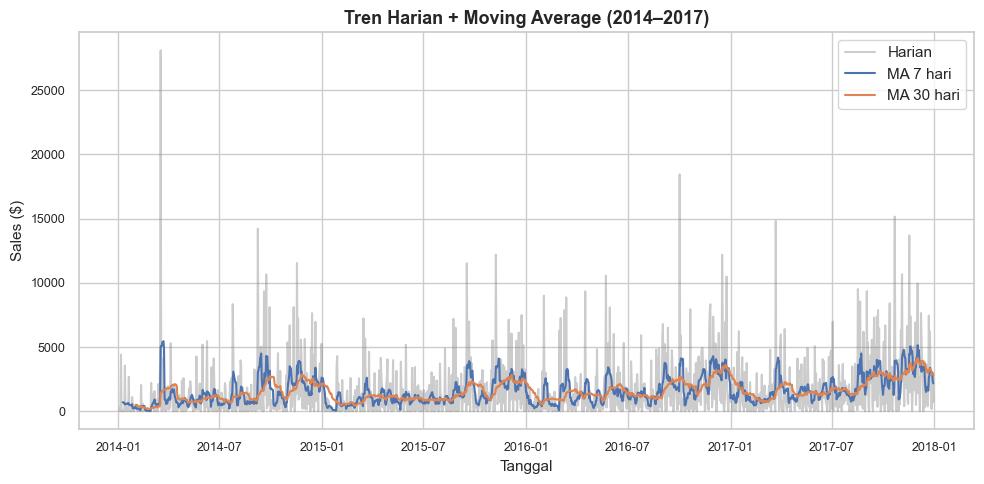

Hari nol penjualan: 221 dari 1458


In [9]:
daily = dfc.set_index("Order Date").resample("D")["Sales"].sum()
fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, color="grey", alpha=0.4, label="Harian")
ax.plot(daily.index, daily.rolling(7).mean(), label="MA 7 hari")
ax.plot(daily.index, daily.rolling(30).mean(), label="MA 30 hari")
ax.set_title("Tren Harian + Moving Average (2014–2017)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Sales ($)")
ax.legend()
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "daily_ma.png"), dpi=150)
print("Hari nol penjualan:", int((daily == 0).sum()), "dari", len(daily))

**Business Insight**

- MA30 naik konsisten 2014 → 2017 dengan spike tiap Q4 — permintaan tumbuh struktural.
- 15% hari nol penjualan (akhir pekan/libur) — level harian terlalu berisik untuk Prophet.
- Agregasi mingguan/bulanan (seperti dipakai app) adalah pilihan tepat.

### Tren mingguan — level forecast operasional

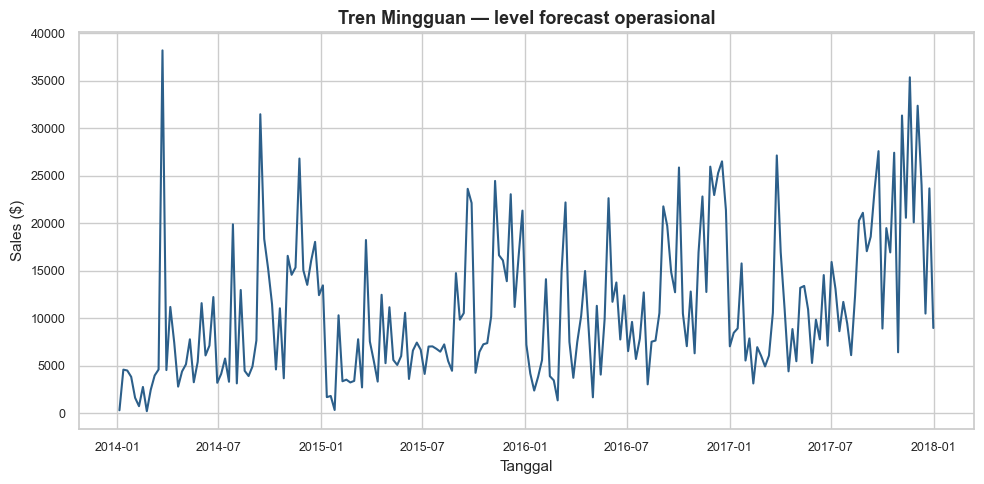

In [10]:
weekly = dfc.set_index("Order Date").resample("W")["Sales"].sum()
fig, ax = plt.subplots()
ax.plot(weekly.index, weekly.values, color=C_SALES)
ax.set_title("Tren Mingguan — level forecast operasional")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Sales ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "weekly_sales_trend.png"), dpi=150)

**Business Insight**

- Fluktuasi mingguan masih kasar tapi pola tahunan mulai terbaca.
- Level ini cocok untuk keputusan operasional jangka pendek (horizon 24 minggu di app).
- Lonjakan akhir tiap tahun berulang — indikasi musiman tahunan.

### Tren bulanan — level forecast strategis

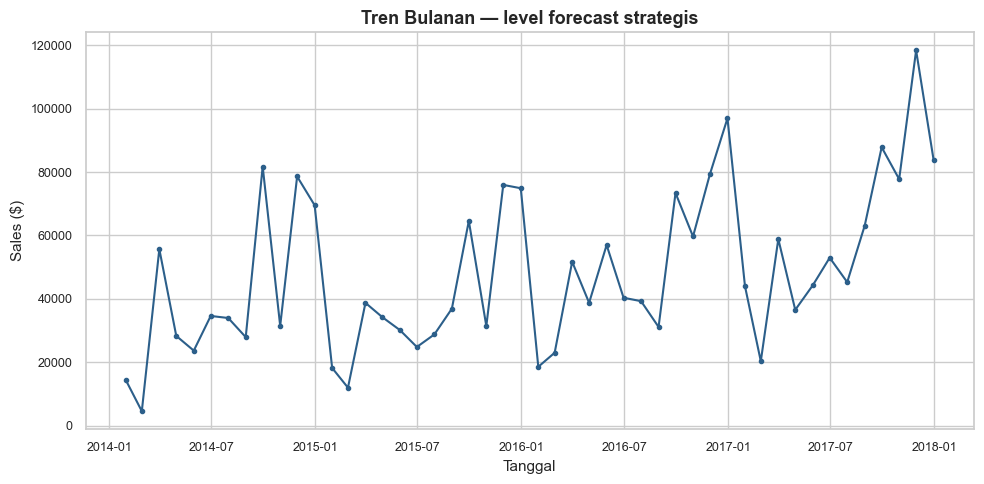

In [11]:
monthly = dfc.set_index("Order Date").resample("ME")["Sales"].sum()
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values, marker="o", ms=3, color=C_SALES)
ax.set_title("Tren Bulanan — level forecast strategis")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Sales ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "monthly_sales_trend.png"), dpi=150)

**Business Insight**

- Tren bulanan paling bersih: arah naik + puncak Q4 berulang tiap tahun.
- Level ini cocok untuk target strategis (horizon 12 bulan di app).
- Pola sekuat ini = sinyal seasonal yang wajib ditangkap model.

## 5. Analisis Musiman

Bedah Sales by Month / Weekday / Quarter — pola yang menjelaskan komponen seasonal model Prophet.

### Sales by Month

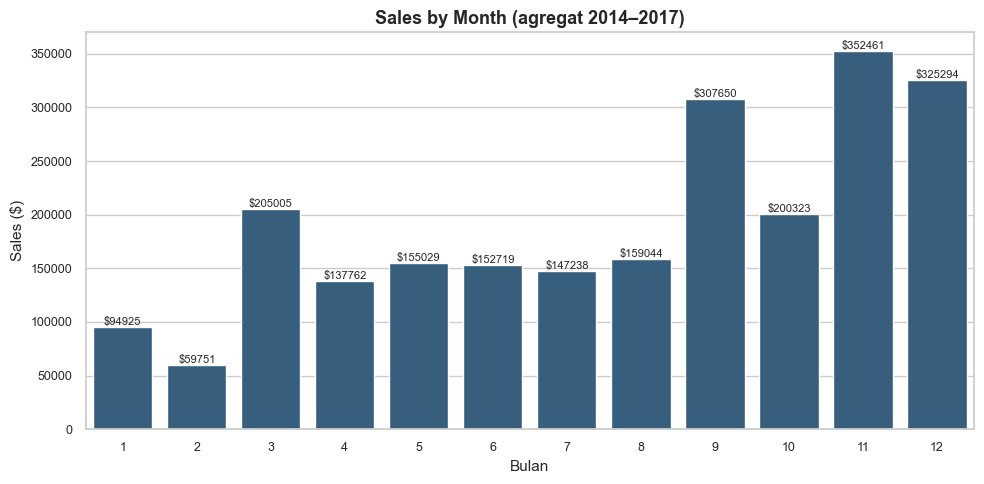

In [12]:
mo = dfc.assign(M=dfc["Order Date"].dt.month).groupby("M")["Sales"].sum()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=mo.index, y=mo.values, ax=ax, color=C_SALES)
vlabel(ax)
ax.set_title("Sales by Month (agregat 2014–2017)")
ax.set_xlabel("Bulan")
ax.set_ylabel("Sales ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "seasonality_month.png"), dpi=150)

**Business Insight**

- November ($352rb), Desember ($325rb), September ($308rb) dominan — musim belanja akhir tahun.
- Februari terendah ($60rb) — awal tahun lesu.
- Stok & promo wajib digenjot menjelang Q4, hemat modal kerja di Q1.

### Sales by Weekday

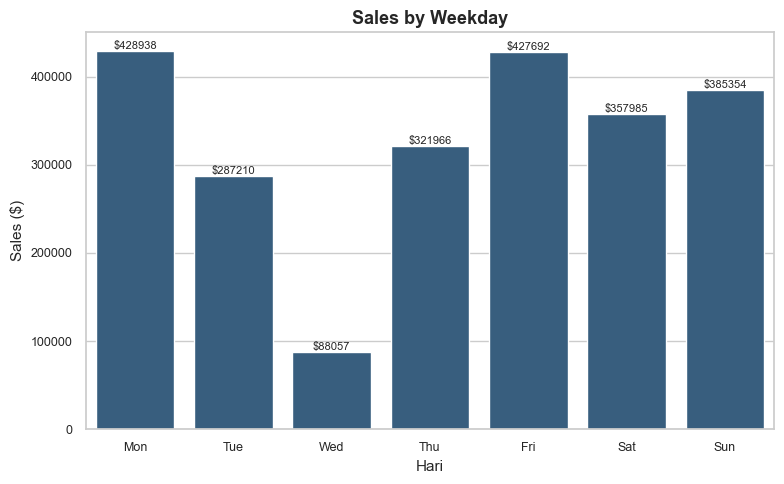

In [13]:
wd = dfc.assign(W=dfc["Order Date"].dt.weekday).groupby("W")["Sales"].sum()
wd.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=wd.index, y=wd.values, ax=ax, color=C_SALES)
vlabel(ax)
ax.set_title("Sales by Weekday")
ax.set_xlabel("Hari")
ax.set_ylabel("Sales ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "seasonality_weekday.png"), dpi=150)

**Business Insight**

- Senin, Jumat, Sabtu, Minggu terkuat ($358–429rb) — belanja akhir pekan + awal pekan.
- Rabu anomali rendah ($88rb) — indikasi efek operasional/kalender.
- Jadwal promo & staffing disesuaikan ke hari kuat; Rabu layak ditandai sebagai outlier kalender.

### Sales by Quarter

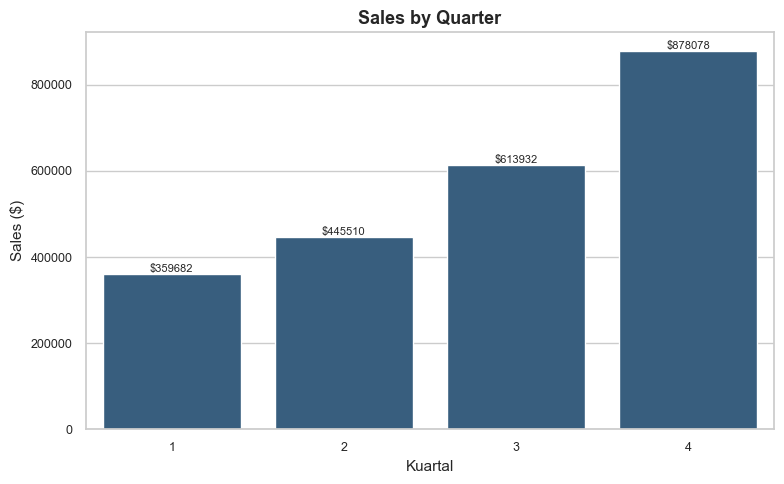

Share revenue: {1: 15.7, 2: 19.4, 3: 26.7, 4: 38.2}


In [14]:
q = dfc.assign(Q=dfc["Order Date"].dt.quarter).groupby("Q")["Sales"].sum()
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=q.index, y=q.values, ax=ax, color=C_SALES)
vlabel(ax)
ax.set_title("Sales by Quarter")
ax.set_xlabel("Kuartal")
ax.set_ylabel("Sales ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "sales_by_quarter.png"), dpi=150)
print("Share revenue:", (q / q.sum() * 100).round(1).to_dict())

**Business Insight**

- Q4 menyumbang 38% revenue tahunan vs Q1 hanya 16%.
- Target tahunan wajib dibobot kuartal — target rata berisiko miss di Q1.
- Efek musiman sekuat ini = alasan utama Prophet (dekomposisi trend + seasonal) dipilih.

## 6. Analisis Bisnis (selaras Dashboard Streamlit)

Section ini mereplikasi tab `Sales_Dashboard.py`: Category, Region, Segment, Sub-Category — agar notebook konsisten dengan aplikasi.

### Sales by Category

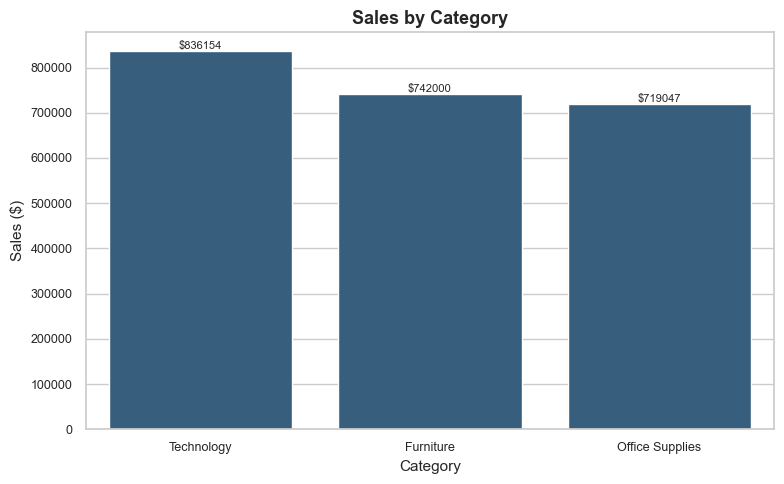

In [15]:
cat = dfc.groupby("Category")["Sales"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=cat.index, y=cat.values, ax=ax, color=C_SALES)
vlabel(ax)
ax.set_title("Sales by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Sales ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "sales_by_category.png"), dpi=150)

**Business Insight**

- Technology ($836rb) > Furniture ($742rb) > Office Supplies ($719rb) — selisih tipis.
- Diversifikasi kategori sehat, tidak tergantung satu kategori.
- Forecast per kategori (next step di Business_Insights) layak diprioritaskan untuk Technology.

### Sales by Region

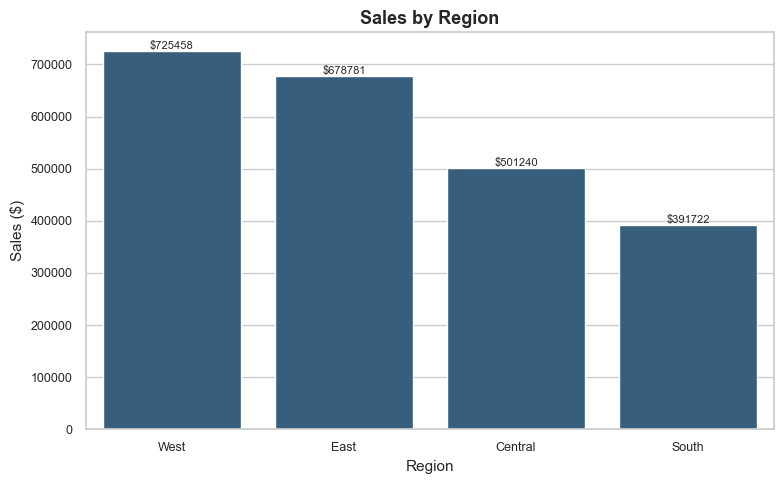

In [16]:
reg = dfc.groupby("Region")["Sales"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=reg.index, y=reg.values, ax=ax, color=C_SALES)
vlabel(ax)
ax.set_title("Sales by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Sales ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "sales_by_region.png"), dpi=150)

**Business Insight**

- West & East memimpin, South & Central tertinggal — gap distribusi antar region.
- Alokasi stok & armada difokuskan ke region kuat menjelang Q4.
- Region lemah butuh diagnosis: daya beli, coverage, atau kompetisi.

### Sales by Segment

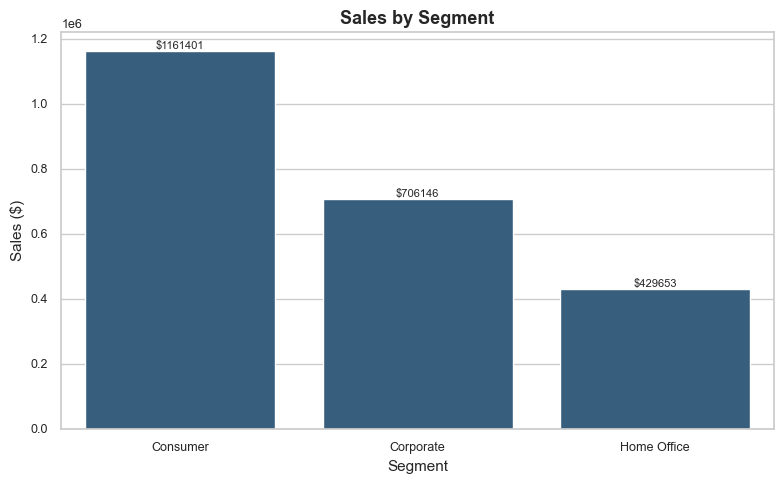

In [17]:
seg = dfc.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=seg.index, y=seg.values, ax=ax, color=C_SALES)
vlabel(ax)
ax.set_title("Sales by Segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Sales ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "sales_by_segment.png"), dpi=150)

**Business Insight**

- Consumer mendominasi, diikuti Corporate, lalu Home Office.
- Strategi marketing mass-market (Consumer) memberi leverage terbesar.
- Segmen Corporate cocok untuk program B2B/enterprise bernilai besar.

### Sales by Sub-Category

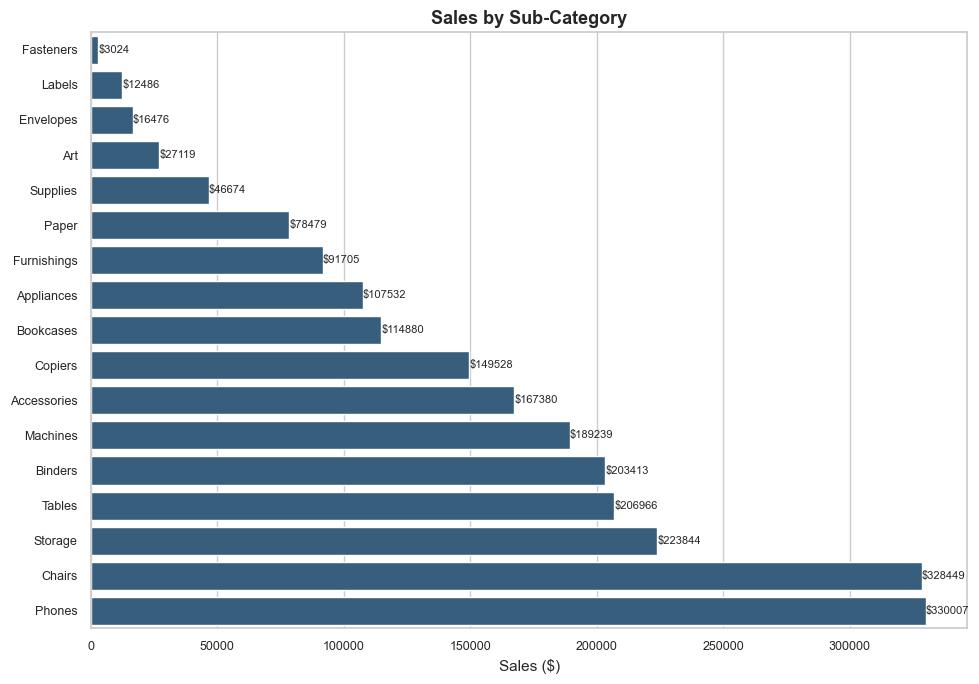

In [18]:
sub = dfc.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=sub.values, y=sub.index, ax=ax, color=C_SALES)
vlabel(ax)
ax.set_title("Sales by Sub-Category")
ax.set_xlabel("Sales ($)")
ax.set_ylabel("")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "sales_by_subcategory.png"), dpi=150)

**Business Insight**

- Phones, Chairs, Storage papan atas — sub-kategori hero pendorong revenue.
- Fasteners, Labels, Envelopes ekor bawah — kontribusi kecil, jaga sebagai pelengkap.
- Stok hero wajib selalu tersedia; stockout di hero paling merugikan.

## 7. Analisis Produk

Top produk by Sales & Profit + Pareto 80/20 — selaras tab Product di dashboard.

### Top 10 Products by Sales

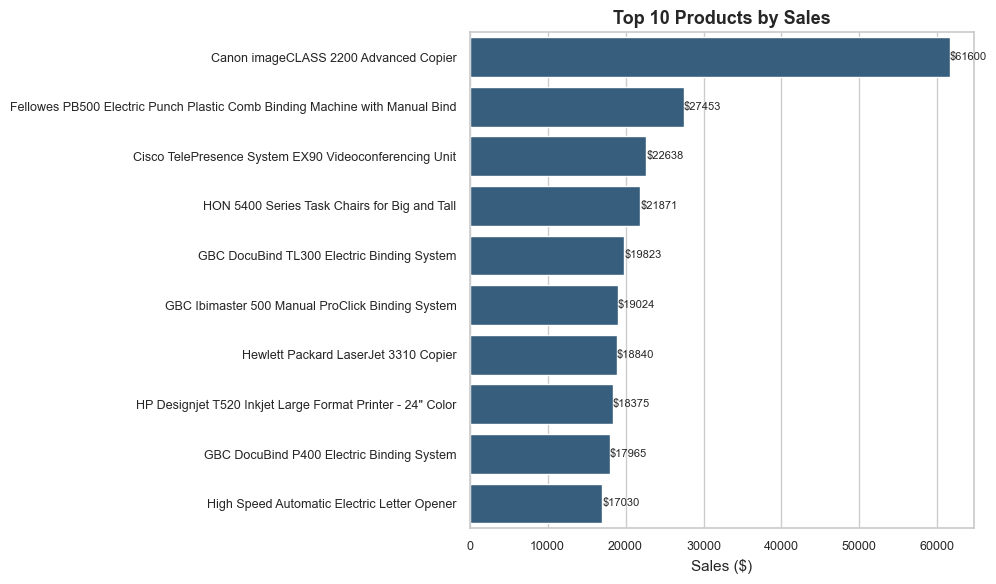

In [19]:
ps = dfc.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=ps.values, y=ps.index, ax=ax, color=C_SALES)
vlabel(ax)
ax.set_title("Top 10 Products by Sales")
ax.set_xlabel("Sales ($)")
ax.set_ylabel("")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "top_products_sales.png"), dpi=150)

**Business Insight**

- Canon imageCLASS 2200 ($61,6rb) top-1 — mesin kantor bernilai besar.
- Top 10 didominasi Technology & Furniture mahal — nilai order ditentukan jenis barang.
- Availability top-SKU wajib diprioritaskan; satu stockout = hilang ribuan dolar.

### Top 10 Products by Profit

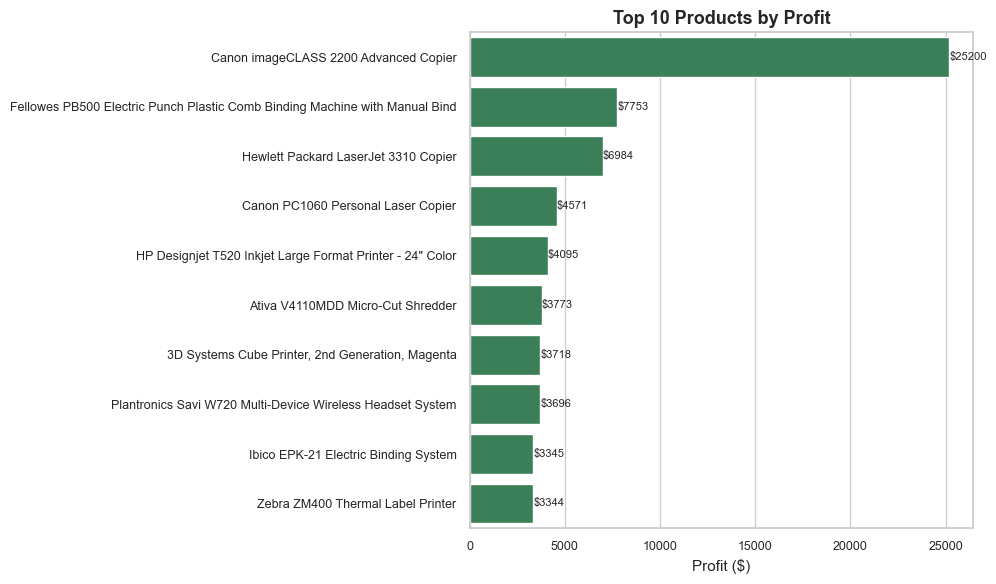

In [20]:
pp = dfc.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=pp.values, y=pp.index, ax=ax, color=C_PROFIT)
vlabel(ax)
ax.set_title("Top 10 Products by Profit")
ax.set_xlabel("Profit ($)")
ax.set_ylabel("")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "top_products_profit.png"), dpi=150)

**Business Insight**

- Daftar top-profit ≠ top-sales — barang termahal belum tentu paling menguntungkan.
- Promo diarahkan ke SKU margin tebal, bukan sekadar SKU laris.
- SKU rugi kronis (lihat scatter Section 8) kandidat delisting atau repricing.

### Pareto Analysis (80/20)

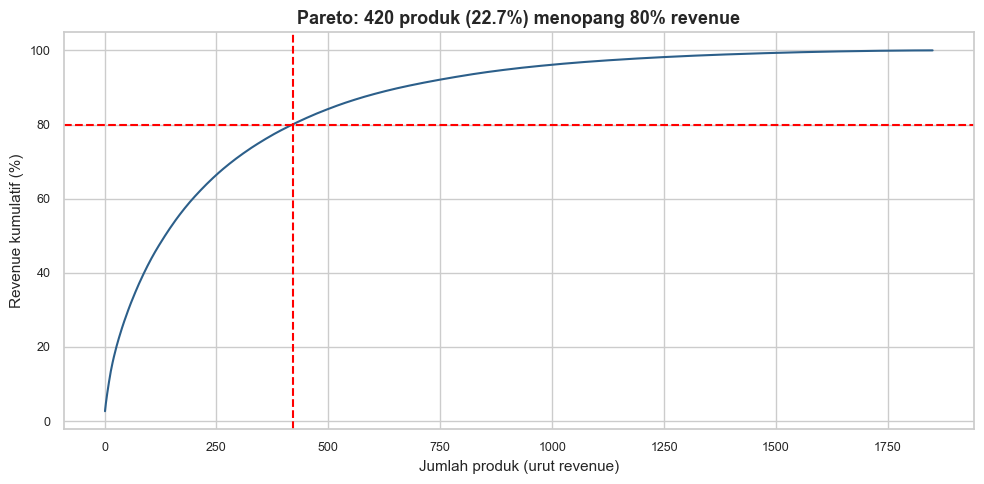

Total produk: 1850 | top-1 share: 2.7%


In [21]:
prod = dfc.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)
cum = (prod.cumsum() / prod.sum() * 100)
n80 = int((cum <= 80).sum()) + 1
fig, ax = plt.subplots()
ax.plot(range(1, len(cum) + 1), cum.values, color=C_SALES)
ax.axhline(80, ls="--", color="red")
ax.axvline(n80, ls="--", color="red")
ax.set_title(f"Pareto: {n80} produk ({n80/len(prod)*100:.1f}%) menopang 80% revenue")
ax.set_xlabel("Jumlah produk (urut revenue)")
ax.set_ylabel("Revenue kumulatif (%)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "pareto.png"), dpi=150)
print(f"Total produk: {len(prod)} | top-1 share: {prod.iloc[0]/prod.sum()*100:.1f}%")

**Business Insight**

- Revenue terkonsentrasi di segelintir SKU — risiko sekaligus peluang fokus.
- Kelola ketat (forecast + safety stock) untuk produk Pareto; long-tail secukupnya.
- Mendukung saran halaman Business_Insights: kembangkan forecast per kategori/SKU hero.

## 8. Distribusi, Outlier & Hubungan Promo

Boxplot + scatter (pengganti histogram gabungan yang kurang informatif) — menjawab: outlier dibuang atau dipertahankan, dan bagaimana diskon memengaruhi laba.

### Boxplot Sales per order

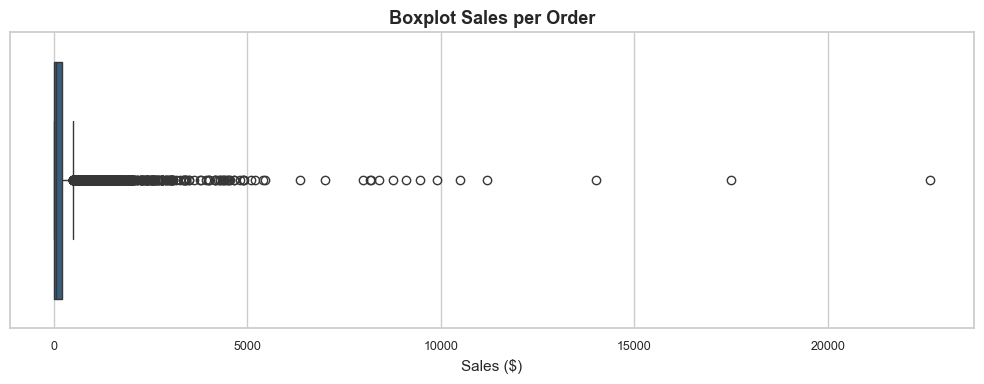

Order Sales>$5.000: 19


In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=dfc["Sales"], ax=ax, color=C_SALES)
ax.set_title("Boxplot Sales per Order")
ax.set_xlabel("Sales ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "boxplot_sales.png"), dpi=150)
print("Order Sales>$5.000:", int((dfc["Sales"] > 5000).sum()))

**Business Insight**

- Hanya 19 order > $5.000 — order B2B valid (copier, server, binding machine), bukan error.
- Outlier dipertahankan: membuangnya memalsukan permintaan dan merusak interval forecast.
- Prophet robust via agregasi M/W + interval `yhat_lower/upper` — pendekatan app sudah benar.

### Boxplot Profit by Category

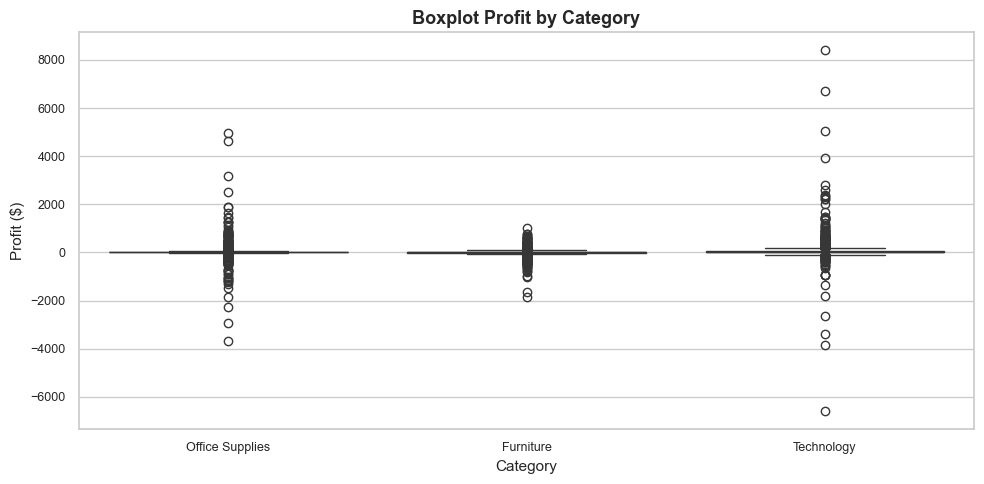

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=dfc, x="Category", y="Profit", ax=ax, hue="Category",
            palette={"Furniture": C_SALES, "Office Supplies": "#5B8DB8", "Technology": C_PROFIT},
            legend=False)
ax.set_title("Boxplot Profit by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Profit ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "boxplot_profit_category.png"), dpi=150)

**Business Insight**

- Furniture ekor rugi terdalam (item besar + diskon agresif) — kategori paling berisiko margin.
- Technology median laba lebih sehat meski ada outlier rugi.
- Review kebijakan diskon Furniture sebelum musim Q4.

### Scatter: Discount vs Profit

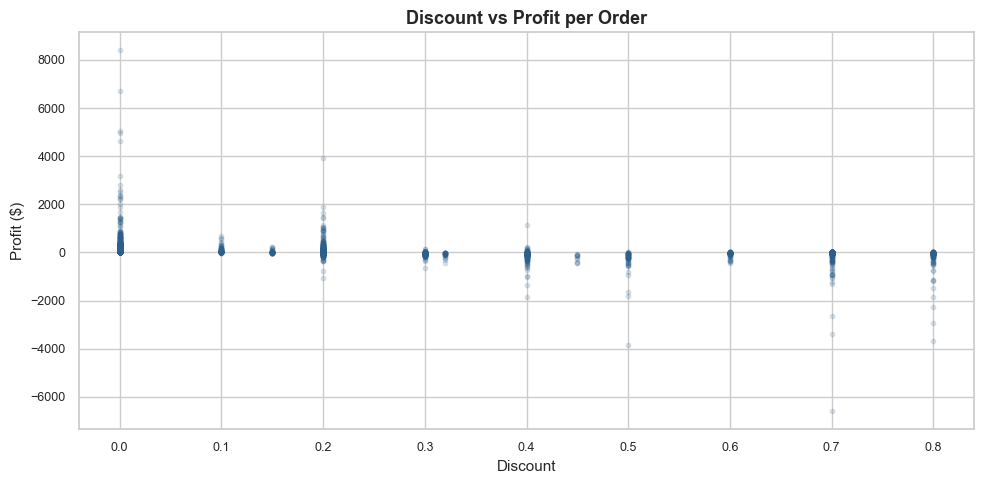

Order rugi: 1871 (18.7%)


In [24]:
fig, ax = plt.subplots()
ax.scatter(dfc["Discount"], dfc["Profit"], alpha=0.15, s=10, color=C_SALES)
ax.set_title("Discount vs Profit per Order")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit ($)")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "scatter_discount_profit.png"), dpi=150)
print("Order rugi:", int((dfc["Profit"] < 0).sum()), f"({(dfc['Profit'] < 0).mean()*100:.1f}%)")

**Business Insight**

- Makin besar diskon, titik profit makin turun ke zona negatif — promo menggerus margin.
- 18,7% order berakhir rugi — subsidi promo nyata, bukan noise.
- Tindak lanjut: batasi diskon > 30%, tambah Discount sebagai regressor Prophet (tahap lanjut).

## 9. Korelasi

Heatmap fitur numerik — relevan untuk insight promo, walau model Prophet tetap univariat.

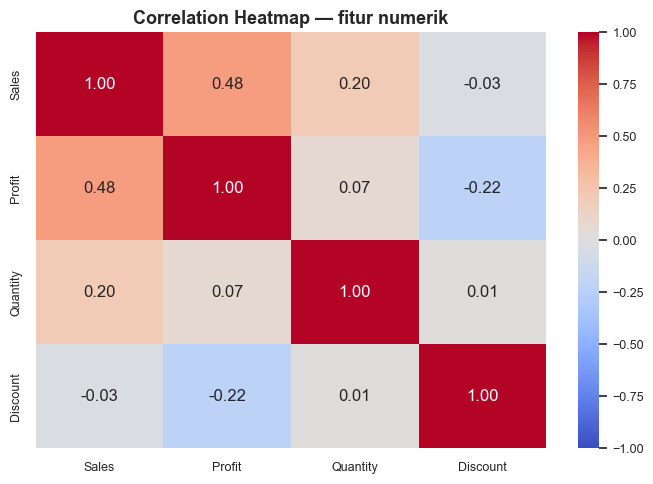

In [25]:
corr = dfc[["Sales", "Profit", "Quantity", "Discount"]].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Heatmap — fitur numerik")
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "correlation_heatmap.png"), dpi=150)

**Business Insight**

- Sales–Profit +0,48 (moderat): omzet naik, laba ikut tapi tidak 1:1 — ada kebocoran margin.
- Discount–Profit −0,22: diskon menekan laba — fokuskan promo ke SKU margin tebal.
- Quantity–Sales hanya +0,20: nilai order ditentukan jenis barang, bukan jumlah unit.

## 10. Forecast Readiness

Cek prasyarat Prophet: missing dates, kontinuitas series agregat, dan stasioneritas visual.

In [26]:
print(f"Hari nol penjualan: {(daily == 0).sum()}/{len(daily)} ({(daily == 0).mean()*100:.1f}%)")
print("Obs bulanan:", len(monthly), "| gap:", int(monthly.isnull().sum()),
      "|", monthly.index.min().date(), "->", monthly.index.max().date())
print("Obs mingguan:", len(weekly), "| gap:", int(weekly.isnull().sum()))

Hari nol penjualan: 221/1458 (15.2%)
Obs bulanan: 48 | gap: 0 | 2014-01-31 -> 2017-12-31
Obs mingguan: 209 | gap: 0


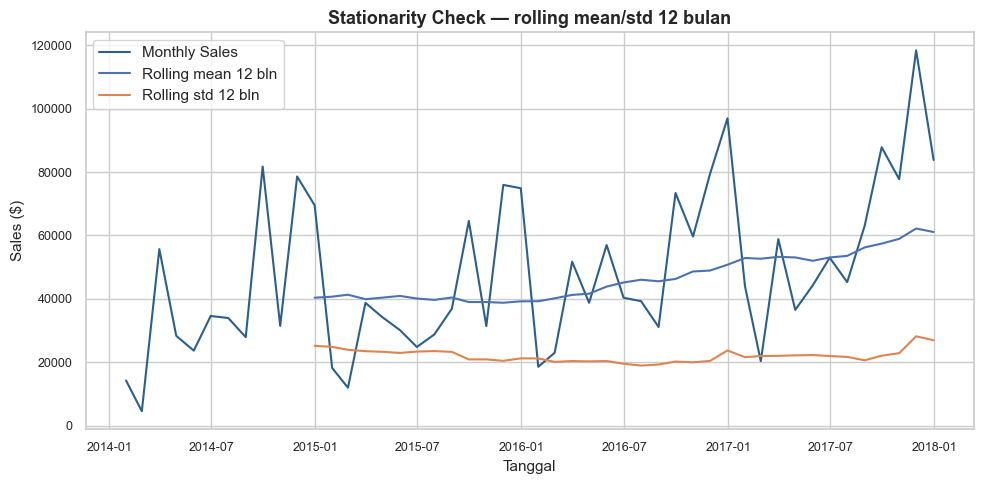

In [27]:
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values, label="Monthly Sales", color=C_SALES)
ax.plot(monthly.index, monthly.rolling(12).mean(), label="Rolling mean 12 bln")
ax.plot(monthly.index, monthly.rolling(12).std(), label="Rolling std 12 bln")
ax.set_title("Stationarity Check — rolling mean/std 12 bulan")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Sales ($)")
ax.legend()
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(FIG, "forecast_readiness.png"), dpi=150)

**Business Insight**

- 15% hari nol → agregasi M (48 obs, nol gap) / W menghilangkan diskontinuitas — series kontinu siap Prophet.
- Rolling mean naik + std melebar → **non-stasioner trend + seasonal**, kasus yang ARIMA mentah gagal tangkap tanpa differencing manual.
- **Prophet cocok karena:** dekomposisi trend + yearly/weekly seasonality otomatis; toleran missing dates & outlier; interval `yhat_lower/upper` untuk risiko stok; dua model M/W menjawab dua horizon keputusan.

## 11. Kesimpulan

| # | Insight utama | Bukti |
|---|---------------|-------|
| 1 | Tren tumbuh struktural 2014 → 2017 | YoY + MA30 (Sec. 4) |
| 2 | Musiman Q4 = 38% revenue; Nov–Des puncak, Feb terendah | Sec. 5 |
| 3 | Rabu anomali rendah — efek kalender/operasional | Weekday (Sec. 5) |
| 4 | Technology unggul tipis; West/East > South/Central; Consumer dominan | Sec. 6 |
| 5 | Revenue terkonsentrasi (Pareto); hero = Phones/Chairs/Storage | Sec. 6–7 |
| 6 | Diskon tekan laba (−0,22); 18,7% order rugi; Furniture paling berisiko | Sec. 8–9 |
| 7 | Series non-stasioner tapi kontinu di M/W → Prophet tepat | Sec. 10 |

**Faktor musiman penentu:** yearly (Q4 holiday), quarterly (Q4 vs Q1), anomali weekday — ketiganya komponen native Prophet.


**Nilai bisnis forecasting:** stok Q4 aman tanpa overstock Q1; target bulanan berbasis data + interval risiko; promo diarahkan ke SKU margin tebal. File `figures/*.png` siap jadi screenshot portfolio/PowerPoint.